# Validación de bounding boxes — Test

**Objetivo:** Verificar visualmente que el detector de rostros genera bounding boxes correctos sobre 5 imágenes aleatorias de cada integrante del equipo (`gerardo`, `miguel`, `kevin`).

**Criterio de aceptación:** detección correcta en al menos el 90% de las imágenes evaluadas. Los casos problemáticos se documentan con una hipótesis de por qué fallan.

## 1. Librerías

In [7]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import random
import sys

def encontrar_raiz_proyecto(inicio):
    for carpeta in [inicio] + list(inicio.parents):
        if (carpeta / "src" / "detector.py").exists():
            return carpeta
    return inicio

RAIZ_PROYECTO = encontrar_raiz_proyecto(Path.cwd())
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))

from src.detector import FaceDetector

## 2. Detector de rostros

Se usa el `FaceDetector` real de `src/detector.py`, que carga los pesos `yolov8n-face.pt` desde `models/`. El detector expone `detect(frame)` que devuelve una lista de tuplas `(x1, y1, x2, y2, confianza)` y `draw_detections(frame, detecciones)` para dibujar las cajas.

In [11]:
# Instancia única del detector real. conf_threshold filtra detecciones
# por debajo de ese nivel de confianza (0.0 a 1.0).
RUTA_PESOS = RAIZ_PROYECTO / "models" / "yolov8n-face.pt"
detector = FaceDetector(str(RUTA_PESOS), conf_threshold=0.5)
print("Detector cargado desde:", RUTA_PESOS)

Detector cargado desde: c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial\models\yolov8n-face.pt


## 3. Carga de imágenes del dataset

Se seleccionan 5 fotos al azar de cada persona en `dataset/known_faces/`.

In [20]:
def encontrar_base_dataset(inicio):
    for carpeta in [inicio] + list(inicio.parents):
        candidato = carpeta / "dataset"
        if candidato.exists():
            return candidato
    return inicio / "dataset"

BASE_DIR = encontrar_base_dataset(Path.cwd())

categorias = {
    "gerardo": BASE_DIR / "known_faces" / "gerardo",
    "miguel":  BASE_DIR / "known_faces" / "miguel",
    "kevin":   BASE_DIR / "known_faces" / "kevin",
}

def cargar_imagenes(carpeta, cantidad=5):
    exts = (".jpg", ".jpeg", ".png")
    if not carpeta.exists():
        return []
    rutas = [p for p in carpeta.rglob("*") if p.is_file() and p.suffix.lower() in exts]
    rutas = sorted(rutas)
    if len(rutas) <= cantidad:
        return rutas
    return random.sample(rutas, cantidad)

imagenes_por_categoria = {nombre: cargar_imagenes(ruta) for nombre, ruta in categorias.items()}
for nombre, rutas in imagenes_por_categoria.items():
    print(f"{nombre}: {len(rutas)} imágenes encontradas")

gerardo: 5 imágenes encontradas
miguel: 5 imágenes encontradas
kevin: 5 imágenes encontradas


## 4. Detección y visualización

Para cada imagen se ejecuta el detector real, se dibujan los bounding boxes encontrados y se muestra el resultado

In [18]:
resultados = []  # guardará dicts: {ruta, categoria, n_boxes, correcto, nota}

def mostrar_resultado(ruta, categoria):
    img = cv2.imread(str(ruta))  # OpenCV lee en BGR
    if img is None:
        print(f" No se pudo leer: {ruta}")
        return None

    detecciones = detector.detect(img)  # [(x1, y1, x2, y2, conf), ...]
    img_con_cajas = detector.draw_detections(img.copy(), detecciones)
    img_rgb = cv2.cvtColor(img_con_cajas, cv2.COLOR_BGR2RGB)  # matplotlib espera RGB

    plt.figure(figsize=(6, 5))
    plt.imshow(img_rgb)
    plt.title(f"{ruta.name} | categoría: {categoria} | rostros: {len(detecciones)}")
    plt.axis("off")
    plt.show()

    return {"ruta": str(ruta), "categoria": categoria, "n_boxes": len(detecciones)}

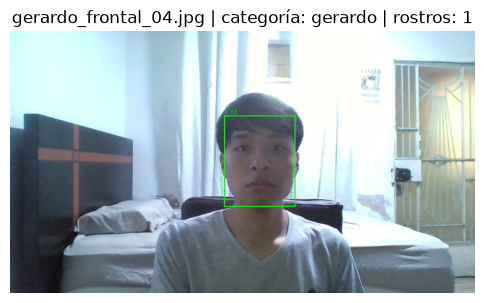

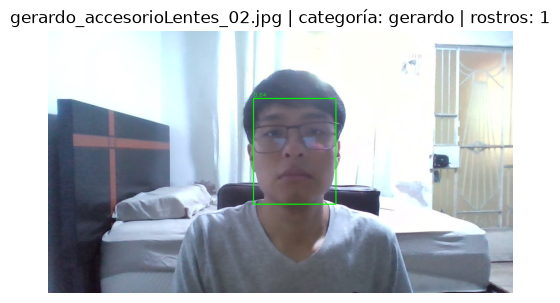

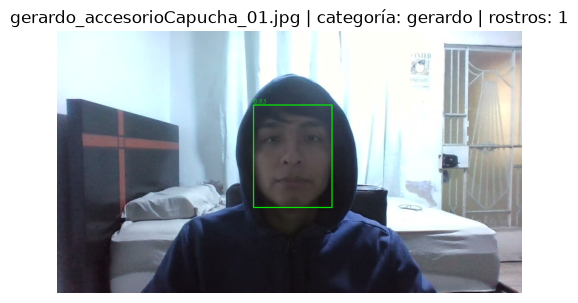

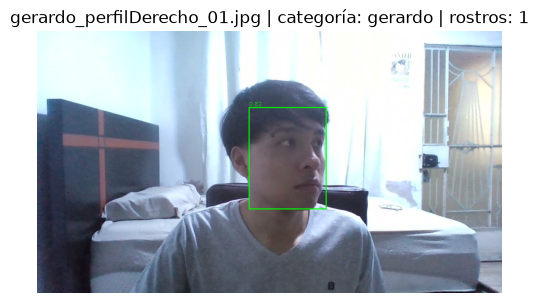

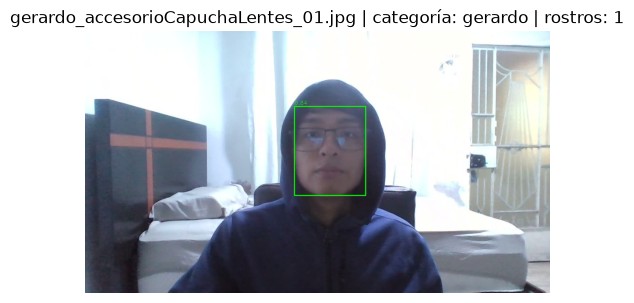

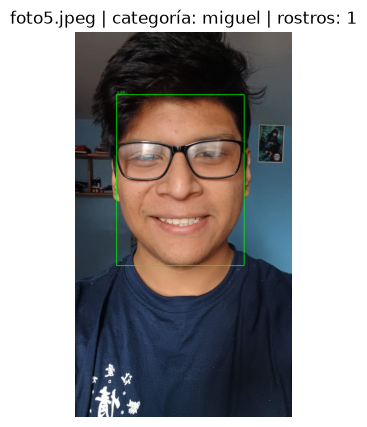

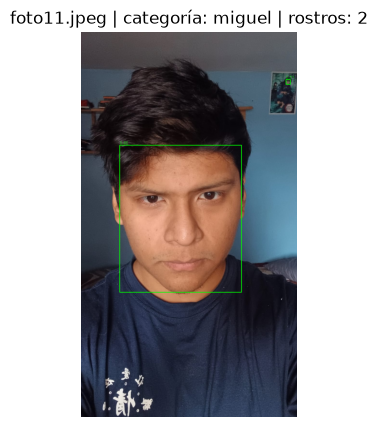

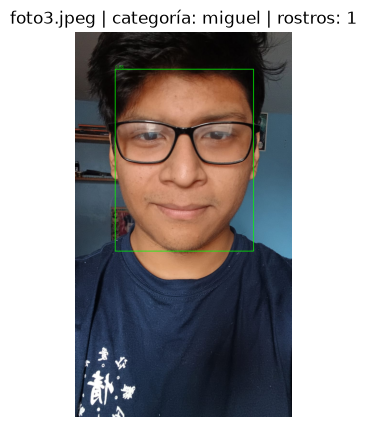

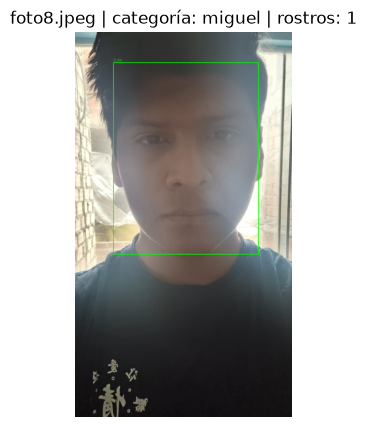

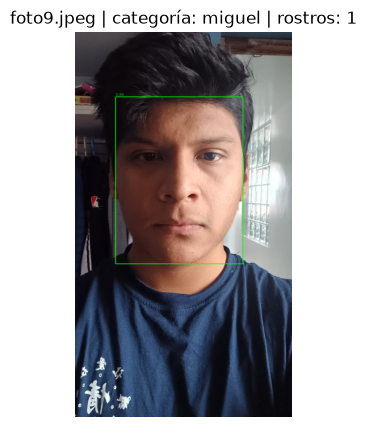

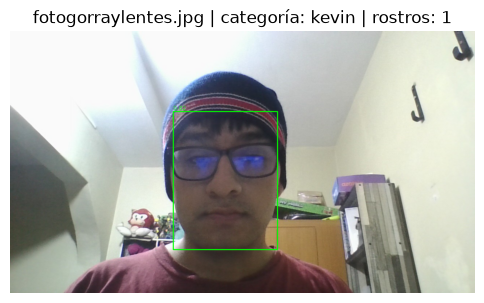

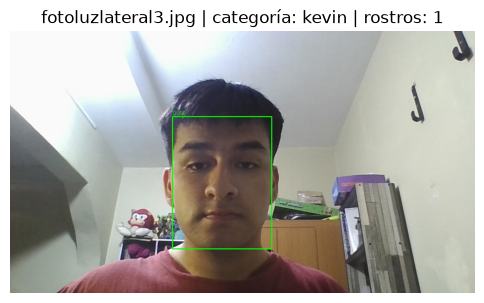

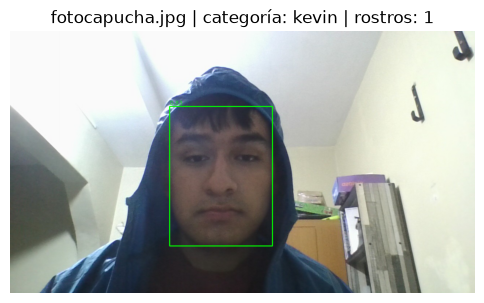

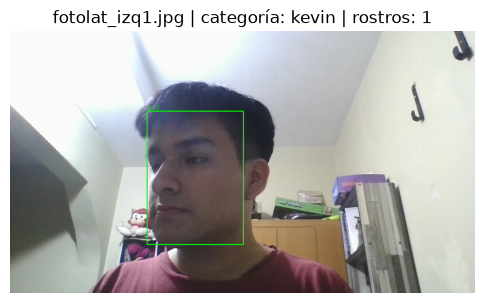

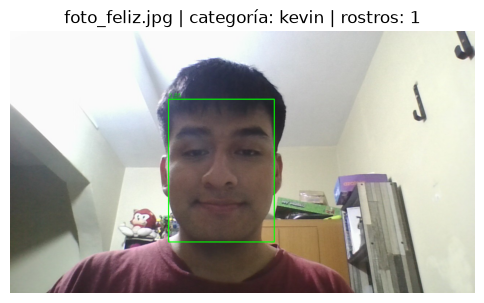

In [21]:
for categoria, rutas in imagenes_por_categoria.items():
    for ruta in rutas:
        r = mostrar_resultado(ruta, categoria)
        if r:
            resultados.append(r)

## 5. Evaluación manual

In [22]:
evaluacion_manual = [
    # --- gerardo ---
    {"ruta": "gerardo/gerardo_frontal_04.jpg",            "correcto": True,  "nota": ""},
    {"ruta": "gerardo/gerardo_accesorioLentes_02.jpg",    "correcto": True,  "nota": "Detecta bien pese a los lentes"},
    {"ruta": "gerardo/gerardo_accesorioCapucha_01.jpg",   "correcto": True,  "nota": "Capucha no afecta"},
    {"ruta": "gerardo/gerardo_perfilDerecho_01.jpg",      "correcto": True,  "nota": "Perfil correctamente encuadrado"},
    {"ruta": "gerardo/gerardo_accesorioCapuchaLentes_01.jpg", "correcto": True, "nota": "Capucha + lentes, ok"},

    # --- miguel ---
    {"ruta": "miguel/foto5.jpeg",  "correcto": True,  "nota": ""},
    {"ruta": "miguel/foto11.jpeg", "correcto": False, "nota": "Falso positivo: caja extra de ~18x20 px sobre una foto enmarcada en la pared (conf 0.51, apenas sobre el umbral 0.5). El rostro principal sí queda bien encuadrado."},
    {"ruta": "miguel/foto3.jpeg",  "correcto": True,  "nota": ""},
    {"ruta": "miguel/foto8.jpeg",  "correcto": True,  "nota": "Poca luz, aun así detecta correctamente"},
    {"ruta": "miguel/foto9.jpeg",  "correcto": True,  "nota": ""},

    # --- kevin ---
    {"ruta": "kevin/fotogorraylentes.jpg", "correcto": True, "nota": "Gorra + lentes + poca luz, caja correcta (conf 0.82)"},
    {"ruta": "kevin/fotoluzlateral3.jpg",  "correcto": True, "nota": "Luz lateral, ok"},
    {"ruta": "kevin/fotocapucha.jpg",      "correcto": True, "nota": ""},
    {"ruta": "kevin/fotolat_izq1.jpg",     "correcto": True, "nota": "Perfil izquierdo bien encuadrado"},
    {"ruta": "kevin/foto_feliz.jpg",       "correcto": True, "nota": ""},
]

total = len(evaluacion_manual)
correctos = sum(1 for e in evaluacion_manual if e["correcto"])
porcentaje = (correctos / total * 100) if total else 0

print(f"Total evaluadas: {total}")
print(f"Correctas: {correctos}")
print(f"Porcentaje de aciertos: {porcentaje:.1f}%")
print(f"Cumple criterio (>=90%): {' SÍ' if porcentaje >= 90 else ' NO'}")

Total evaluadas: 15
Correctas: 14
Porcentaje de aciertos: 93.3%
Cumple criterio (>=90%):  SÍ


## 6. Resumen de resultados

- **Total de imágenes probadas:** 15 (5 por persona: gerardo, miguel, kevin)
- **Detecciones correctas:** 14 / 15 (93.3%) → **cumple el criterio del ≥90%**
- **Casos problemáticos observados:**
  - `miguel/foto11.jpeg` → **falso positivo**: el detector marcó una "cara" de ~18×20 px dentro de una foto enmarcada colgada en la pared. Salió con confianza **0.51**, apenas por encima del umbral 0.5. El rostro principal sí quedó bien encuadrado.
- **Conclusión:** el detector `yolov8n-face.pt` funciona bien en las condiciones probadas: aguanta lentes, capucha, perfil y poca luz, con confianzas de 0.80+ en los rostros reales. El único fallo es el falso positivo, que se resuelve **subiendo `conf_threshold` a ~0.6** (elimina la caja falsa sin perder rostros reales).

> **Nota sobre el alcance del test:** se evaluaron solo **5 imágenes aleatorias por persona** (15 en total), elegidas con `random.sample` **sin semilla fija**, así que cada corrida prueba un subconjunto distinto. Por eso este 93.3% es **indicativo, no definitivo**: condiciones más difíciles (perfiles extremos, contraluz fuerte, varias personas en cuadro, rostros muy pequeños) podrían estar sub-representadas o no haber salido en esta muestra. Para una validación más sólida convendría correr el test varias veces o evaluar el dataset completo de cada persona.